# From a forecast to an inventory decision

This notebook connects a small external forecast to a Stockcast replenishment decision and then follows the inventory result on held-out demand.

```text
demand history → cumulative forecast → protection target → order decision → inventory simulation
```

**Timing migration.** Decisions now precede current demand. `lead_time=0` means immediate receipt; positive lead times count forward from the decision epoch. Decision schedules use zero-based demand periods, while state/callback periods retain their existing coordinates. Forecasts exclude current demand. Numerical results from the former demand-first engine must be regenerated.


A forecast is not yet an inventory decision. Smooth estimates future demand and its uncertainty. Stockcast receives one dated protection target, compares it with the current inventory position, places replenishment orders, and evaluates what happens operationally.

In [2]:
# Section 1: table tools for the history/holdout split.
import pandas as pd


In [3]:
# These settings define one small daily inventory scenario.
sku = 'tea_250g'
forecast_origin = pd.Timestamp('2026-02-14')
period_frequency = 'D'
lead_time = 2
review_period = 2
service_level = 0.95
# An (R, S) target protects demand until the next order can arrive.
protection_horizon = lead_time + review_period


## 1. Split history from held-out demand

The history is available at the forecast origin and is used to fit the forecast. The later values are kept separate: they become the realized demand used by the inventory simulation.

In [4]:
# Only these observations are available when the forecast is created.
history = pd.DataFrame({
    'unique_id': [sku] * 10,
    'date': pd.date_range(end=forecast_origin, periods=10, freq=period_frequency),
    'y': [5.0, 6.0, 4.0, 7.0, 6.0, 5.0, 8.0, 6.0, 5.0, 7.0],
})

# The holdout is kept separate and later becomes realized simulation demand.
holdout_values = [7.0, 5.0, 8.0, 6.0, 4.0, 7.0, 6.0, 9.0, 5.0, 6.0, 7.0, 5.0]
holdout = pd.DataFrame({
    'unique_id': [sku] * len(holdout_values),
    'period': range(len(holdout_values)),
    'date': pd.date_range(
        forecast_origin + pd.Timedelta(days=1),
        periods=len(holdout_values),
        freq=period_frequency,
    ),
    'y': holdout_values,
})


In [5]:
# Ten observed days end exactly at the forecast origin.
assert history['date'].max() == forecast_origin
assert len(history) == 10

history


,unique_id,date,y
0,tea_250g,2026-02-05,5.0
1,tea_250g,2026-02-06,6.0
2,tea_250g,2026-02-07,4.0
3,tea_250g,2026-02-08,7.0
4,tea_250g,2026-02-09,6.0
5,tea_250g,2026-02-10,5.0
6,tea_250g,2026-02-11,8.0
7,tea_250g,2026-02-12,6.0
8,tea_250g,2026-02-13,5.0
9,tea_250g,2026-02-14,7.0


In [6]:
# Twelve held-out days begin the day after the origin and never overlap history.
assert holdout['date'].min() == forecast_origin + pd.Timedelta(days=1)
assert holdout['date'].min() > history['date'].max()
assert len(holdout) == 12

holdout


,unique_id,period,date,y
0,tea_250g,0,2026-02-15,7.0
1,tea_250g,1,2026-02-16,5.0
2,tea_250g,2,2026-02-17,8.0
3,tea_250g,3,2026-02-18,6.0
4,tea_250g,4,2026-02-19,4.0
5,tea_250g,5,2026-02-20,7.0
6,tea_250g,6,2026-02-21,6.0
7,tea_250g,7,2026-02-22,9.0
8,tea_250g,8,2026-02-23,5.0
9,tea_250g,9,2026-02-24,6.0


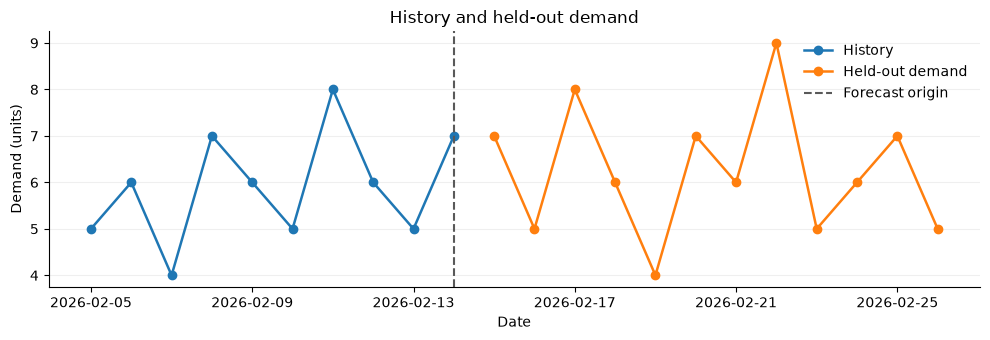

In [7]:
# Section 1 plot: history versus held-out demand around the origin.
import matplotlib.pyplot as plt

# Plot the data boundary before fitting the forecasting model.
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(history['date'], history['y'], marker='o', linewidth=1.8, label='History')
ax.plot(holdout['date'], holdout['y'], marker='o', linewidth=1.8, label='Held-out demand')
ax.axvline(forecast_origin, color='0.35', linestyle='--', label='Forecast origin')
ax.set(title='History and held-out demand', xlabel='Date', ylabel='Demand (units)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


## 2. Forecast cumulative demand over the protection horizon

Smooth is an external forecasting package, installed separately from Stockcast. We fit a simple `ES(model='ANN')` model to the history. Its error model is normal.

The inventory target must cover the time until the next replenishment opportunity:

```text
protection horizon = lead time + review period = 2 + 2 = 4 days
```

`cumulative=True` asks Smooth for total demand across those four days. We use the cumulative upper prediction bound at the 95% service level—not a point forecast and not a sum of separate daily interval bounds.

In [8]:
# Section 2: external forecast fit on history only; holdout stays unseen.
from smooth import ES

# Fit one univariate exponential-smoothing model to the observed history.
model = ES(model='ANN')
model.fit(history['y'])

# This forecast keeps the four daily predictions separate for inspection.
daily_forecast = model.predict(
    h=protection_horizon,
    interval='prediction',
    level=service_level,
    side='upper',
    cumulative=False,
)

# This second call asks Smooth for the distribution of the four-day total.
cumulative_forecast = model.predict(
    h=protection_horizon,
    interval='prediction',
    level=service_level,
    side='upper',
    cumulative=True,
)

In [9]:
forecast_dates = pd.date_range(
    forecast_origin + pd.Timedelta(days=1),
    periods=protection_horizon,
    freq=period_frequency,
)
daily_forecast_output = pd.DataFrame({
    'date': forecast_dates,
    'forecast_mean': daily_forecast.mean.to_numpy(),
    'daily_upper_95': daily_forecast.upper.iloc[:, 0].to_numpy(),
    'heldout_demand': holdout.loc[:protection_horizon - 1, 'y'].to_numpy(),
})
# Summing daily means is valid for showing expected cumulative demand.
daily_forecast_output['cumulative_mean'] = daily_forecast_output['forecast_mean'].cumsum()
daily_forecast_output['cumulative_heldout'] = daily_forecast_output['heldout_demand'].cumsum()

target_end_date = forecast_dates[-1]
forecast_output = pd.DataFrame({
    'unique_id': [sku],
    'forecast_origin': [forecast_origin],
    'horizon_days': [protection_horizon],
    'target_end_date': [target_end_date],
    'cumulative_mean': [float(cumulative_forecast.mean.iloc[-1])],
    'cumulative_upper_95': [float(cumulative_forecast.upper.iloc[-1, 0])],
})

In [10]:
# Four daily means with separate upper bounds, beside demand later observed.
daily_forecast_output.round(3)


/tmp/ipykernel_1168273/4124289831.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  daily_forecast_output.round(3)


,date,forecast_mean,daily_upper_95,heldout_demand,cumulative_mean,cumulative_heldout
0,2026-02-15,5.9,7.989,7.0,5.9,7.0
1,2026-02-16,5.9,7.989,5.0,11.8,12.0
2,2026-02-17,5.9,7.989,8.0,17.7,20.0
3,2026-02-18,5.9,7.989,6.0,23.6,26.0


In [11]:
# Direct cumulative forecast used for the inventory target.
# This upper bound is calculated directly, never by summing daily bounds.
forecast_output.round(3)


/tmp/ipykernel_1168273/3080337208.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  forecast_output.round(3)


,unique_id,forecast_origin,horizon_days,target_end_date,cumulative_mean,cumulative_upper_95
0,tea_250g,2026-02-14,4,2026-02-18,23.6,27.777


### See cumulative demand as a growing total

Daily demand bounces up and down, but its running total only grows. That growing line is what the policy target must cover: the orange line accumulates the forecast means, the green line accumulates the demand later observed, and the diamond is Smooth's directly calculated upper bound for the four-day total.


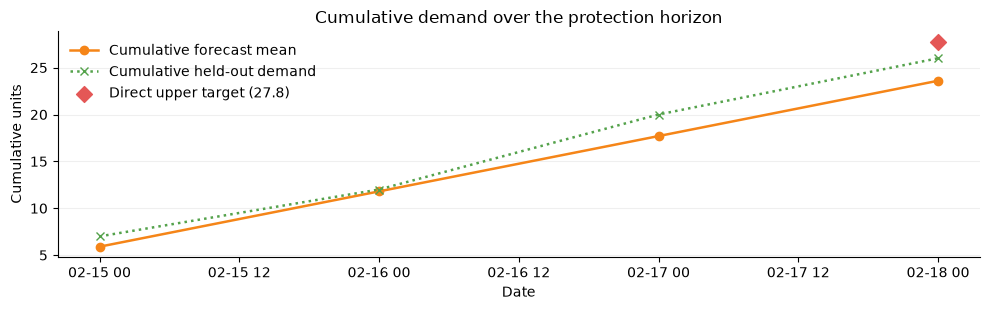

In [12]:
# Plot the running totals before comparing daily and cumulative views side by side.
# The diamond sits above the mean line: it is the 95% upper bound, not a point forecast.
protection_target = float(forecast_output.loc[0, 'cumulative_upper_95'])
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(daily_forecast_output['date'], daily_forecast_output['cumulative_mean'],
        color='#F58518', marker='o', linewidth=1.8, label='Cumulative forecast mean')
ax.plot(daily_forecast_output['date'], daily_forecast_output['cumulative_heldout'],
        color='#54A24B', marker='x', linestyle=':', linewidth=1.8, label='Cumulative held-out demand')
ax.scatter([target_end_date], [protection_target], marker='D', s=65,
           color='#E45756', zorder=3, label=f'Direct upper target ({protection_target:.1f})')
ax.set(title='Cumulative demand over the protection horizon', xlabel='Date', ylabel='Cumulative units')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

# Summing the daily means must recover the direct cumulative mean.
assert abs(daily_forecast_output['cumulative_mean'].iloc[-1] - float(forecast_output.loc[0, 'cumulative_mean'])) < 1e-6


### See the daily forecast and its cumulative meaning

The left panel shows the separate daily prediction means and upper bounds. The right panel accumulates only the daily means and the later observed demand. The diamond is different: it is Smooth's directly calculated upper bound for total four-day demand, which becomes the protection target. We do not add the daily upper bounds together.

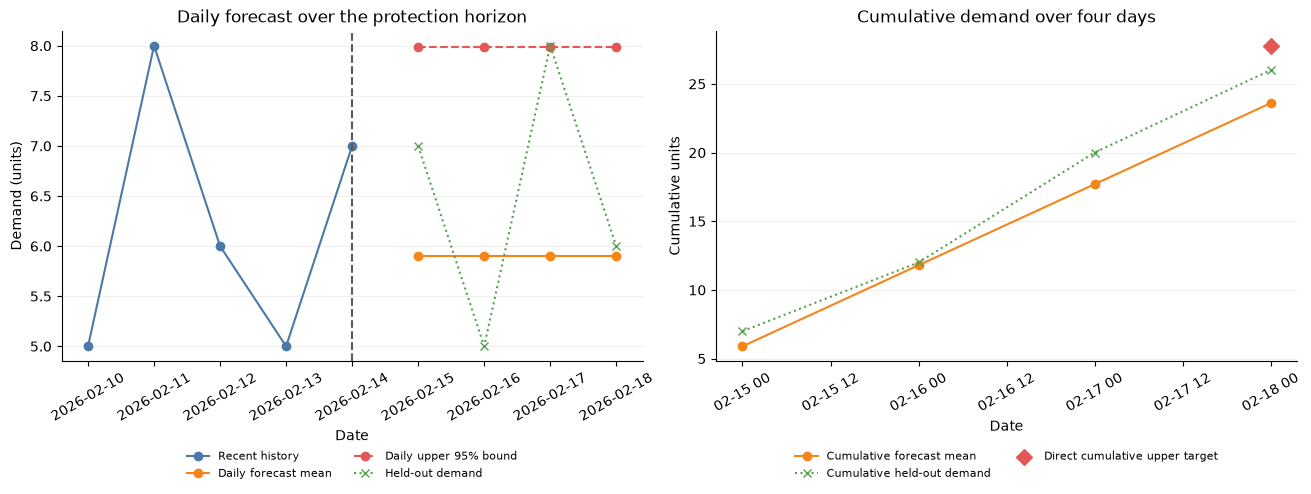

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout='constrained')

# Daily view: compare the forecast with the demand later observed in the holdout.
axes[0].plot(history.tail(5)['date'], history.tail(5)['y'], marker='o', color='#4C78A8', label='Recent history')
axes[0].plot(daily_forecast_output['date'], daily_forecast_output['forecast_mean'], marker='o', color='#F58518', label='Daily forecast mean')
axes[0].plot(daily_forecast_output['date'], daily_forecast_output['daily_upper_95'], marker='o', linestyle='--', color='#E45756', label='Daily upper 95% bound')
axes[0].plot(daily_forecast_output['date'], daily_forecast_output['heldout_demand'], marker='x', linestyle=':', color='#54A24B', label='Held-out demand')
axes[0].axvline(forecast_origin, color='0.35', linestyle='--')
axes[0].set(title='Daily forecast over the protection horizon', xlabel='Date', ylabel='Demand (units)')

# Cumulative view: the final diamond is the direct protection target.
protection_target = float(forecast_output.loc[0, 'cumulative_upper_95'])
axes[1].plot(daily_forecast_output['date'], daily_forecast_output['cumulative_mean'], marker='o', color='#F58518', label='Cumulative forecast mean')
axes[1].plot(daily_forecast_output['date'], daily_forecast_output['cumulative_heldout'], marker='x', linestyle=':', color='#54A24B', label='Cumulative held-out demand')
axes[1].scatter(target_end_date, protection_target, marker='D', s=65, color='#E45756', zorder=3, label='Direct cumulative upper target')
axes[1].set(title='Cumulative demand over four days', xlabel='Date', ylabel='Cumulative units')

for ax in axes:
    # One tick per day keeps the short horizon easy to scan.
    ax.tick_params(axis='x', rotation=30)
    ax.legend(frameon=False, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=2)
    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()


## 3. Turn the cumulative forecast into a Stockcast target

The handoff is a small table. The target value comes directly from Smooth's cumulative upper bound, while the other columns explain exactly what that value represents. `external_direct` tells Stockcast that the cumulative target was calculated outside the package.

In [14]:
# Keep the numerical target and its date/probability meaning in one row.
target = pd.DataFrame({
    'unique_id': [sku],
    'protection_target': [forecast_output.loc[0, 'cumulative_upper_95']],
    'target_probability': [service_level],
    'protection_horizon': [protection_horizon],
    'forecast_origin': [forecast_origin],
    'forecast_frequency': [period_frequency],
    'target_end_date': [target_end_date],
    'representation': ['cumulative_upper_prediction_interval'],
    'target_source': ['external_direct'],
})
target


,unique_id,protection_target,target_probability,protection_horizon,forecast_origin,forecast_frequency,target_end_date,representation,target_source
0,tea_250g,27.77741,0.95,4,2026-02-14,D,2026-02-18,cumulative_upper_prediction_interval,external_direct


## 4. Convert the target into an order decision

Opening stock is a separate inventory input; it is not estimated from the forecast. The `(R, S)` policy compares the target `S` with inventory position and requests the difference.

In [15]:
# Opening stock is a declared inventory input, independent of the forecast.
opening_stock = pd.DataFrame({'unique_id': [sku], 'observed_on_hand': [12.0]})
opening_stock


,unique_id,observed_on_hand
0,tea_250g,12.0


In [16]:
# Section 4: inventory holding on-hand, pipeline, and backlog.
from stockcast import InventoryStateDataFrame

# Your working object; the engine deep-copies it at run time.
opening_inventory = InventoryStateDataFrame(
    [sku], max_lead_time=lead_time, allow_backorders=False
).initialize_from_observed(
    opening_stock,
    on_hand_column='observed_on_hand',
    start_date=forecast_origin,
)
opening_inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=12, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [17]:
# Section 4 continued: order-up-to policy fed by the external target.
from stockcast import OrderUpToPolicy

# Fitting validates that the target matches this policy's service level and horizon.
policy = OrderUpToPolicy(
    lead_time=lead_time,  # 2-day delivery delay; order enters pipeline, not on-hand.
    review_period=review_period,  # Review every 2 days; only those periods may order.
    service_level=service_level,  # 95% protection; must match target_probability below.
    allow_backorders=False,  # Lost sales; matches the opening state, unmet demand is lost.
).fit(
    target,  # One externally calculated cumulative target row for this SKU.
    target_column='protection_target',  # S value: direct 4-day cumulative upper bound.
    target_probability=service_level,  # Same 95% variable; fail-closed match to service_level.
    protection_horizon=protection_horizon,  # H = 2 + 2 = 4 days of demand to cover.
    target_source='external_direct',  # Asserts Smooth's bound is used as-is; no aggregation.
    forecast_origin=forecast_origin,  # Info date; history ends here, holdout starts next day.
    forecast_frequency=period_frequency,  # Daily steps; must match demand and state frequency.
    target_end_date_column='target_end_date',  # Must equal origin + H; validated.
)

# The policy orders up from inventory position to the fitted target level.
opening_decision = policy.predict(opening_inventory, current_period=0)
print('Opening inventory')
print(opening_inventory.inventory_position()[[
    'unique_id', 'on_hand', 'total_in_transit', 'inventory_position'
]].to_string(index=False))
print('\nOrder decision')
print(opening_decision.get_dataframe().round(3).to_string(index=False))


Opening inventory
unique_id  on_hand  total_in_transit  inventory_position
 tea_250g     12.0               0.0                12.0

Order decision
unique_id  order_quantity  target_level  inventory_position  reorder_point  order_period  expected_delivery_period
 tea_250g          15.777        27.777                12.0            NaN             0                         2


## 5. Simulate inventory on the held-out demand

The engine starts with the declared opening stock, makes the opening decision, and then processes the twelve held-out days. Orders take two days to arrive. The run uses two warm-up days, eight scoring days, and a two-day settlement tail.

In [18]:
# Section 5: engine replays the 12 held-out days under the fitted policy.
from stockcast import SimulationEngine

# The engine receives the held-out demand exactly as declared above.
result = SimulationEngine().run(
    policy=policy,  # Fitted (R,S) policy; engine deep-copies it.
    demand_source=holdout,  # 12 realized days unseen by the forecast; consumed in every window.
    inventory=opening_inventory,  # Explicit opening state at the origin; also deep-copied.
    n_periods=len(holdout),  # All 12 holdout rows; must equal warmup + scoring + settlement.
    period_frequency=period_frequency,  # 'D': one engine step per demand date, forward only.
    # Place the first policy order before the first held-out demand arrives.
    initial_decision='none',
    # Every day advances inventory, but only the middle eight days are scored.
    warmup_periods=2,  # Settle opening effects; advances demand but excluded from scoring.
    scoring_periods=8,  # Middle segment feeding the metrics below.
    settlement_periods=2,  # Tail demand shown with new review orders disabled here.
    order_during_settlement=False,  # Settlement still advances demand, but suppresses new orders.
    demand_source_name='declared_heldout_tea_demand',  # Provenance label kept in the manifest.
    random_seed=None,  # Fully declared holdout, no random generator involved.
)


In [19]:
# This is the engine's copy; `opening_inventory` above is unchanged.
result.inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=5, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

## 6. Read the operational result

The event table is Stockcast's accounting record. It shows when demand occurred, when accepted orders entered the pipeline, when they arrived as physical stock, and how much inventory remained.

In [20]:
# Keep every run window so order and receipt timing remains visible end to end.
events = result.to_event_frame(window='all')
period_events = events.loc[events['event_type'].eq('period')].copy()
event_columns = [
    'run_window', 'date', 'demand', 'order_quantity', 'received_units',
    'ending_on_hand', 'on_order_end', 'shortage_units',
]
print(f"Period rows: {len(period_events)} (warm-up, scoring, settlement)")
print(f"Scoring rows: {(period_events['run_window'] == 'scoring').sum()}")
print(period_events[event_columns].round(3).to_string(index=False))


Period rows: 12 (warm-up, scoring, settlement)
Scoring rows: 8
run_window       date  demand  order_quantity  received_units  ending_on_hand  on_order_end  shortage_units
    warmup 2026-02-15     7.0          15.777           0.000           5.000        15.777             0.0
    warmup 2026-02-16     5.0           0.000           0.000           0.000        15.777             0.0
   scoring 2026-02-17     8.0          12.000          15.777           7.777        12.000             0.0
   scoring 2026-02-18     6.0           0.000           0.000           1.777        12.000             0.0
   scoring 2026-02-19     4.0          14.000          12.000           9.777        14.000             0.0
   scoring 2026-02-20     7.0           0.000           0.000           2.777        14.000             0.0
   scoring 2026-02-21     6.0          11.000          14.000          10.777        11.000             0.0
   scoring 2026-02-22     9.0           0.000           0.000           1

/tmp/ipykernel_1168273/2817273925.py:10: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(period_events[event_columns].round(3).to_string(index=False))


In [21]:
print('Target metadata retained by the simulation')
print(pd.DataFrame([result.run_manifest['policy']['target_metadata']]).to_string(index=False))


Target metadata retained by the simulation
                 representation  target_probability  protection_horizon   target_source     forecast_origin forecast_frequency     target_end_date
direct_protection_period_target                0.95                   4 external_direct 2026-02-14T00:00:00                  D 2026-02-18T00:00:00


In [22]:
# Section 6: scoring-window metrics from validated events, not plots.
from stockcast.evaluation import (
    InventoryEvaluator, avg_on_hand, demand_period_service_level,
    fill_rate, order_units,
)

# Metrics are calculated only from validated scoring-window event rows.
metrics = InventoryEvaluator().fit(
    simulation_result=result, window='scoring'
).evaluate(
    metrics=[fill_rate, demand_period_service_level, avg_on_hand, order_units],
    groupby=[],
)
print('Scoring-window metrics')
print(metrics.round(3).to_string(index=False))


Scoring-window metrics
 fill_rate  demand_period_service_level  avg_on_hand  order_units
       1.0                          1.0        5.527         52.0


### See demand, replenishment, and inventory together

The middle panel separates orders from receipts. An order is accepted into the lead-time pipeline when it is placed; it becomes physical stock only when it appears as a receipt. The bottom panel therefore shows on-hand stock and unreceived pipeline stock separately.

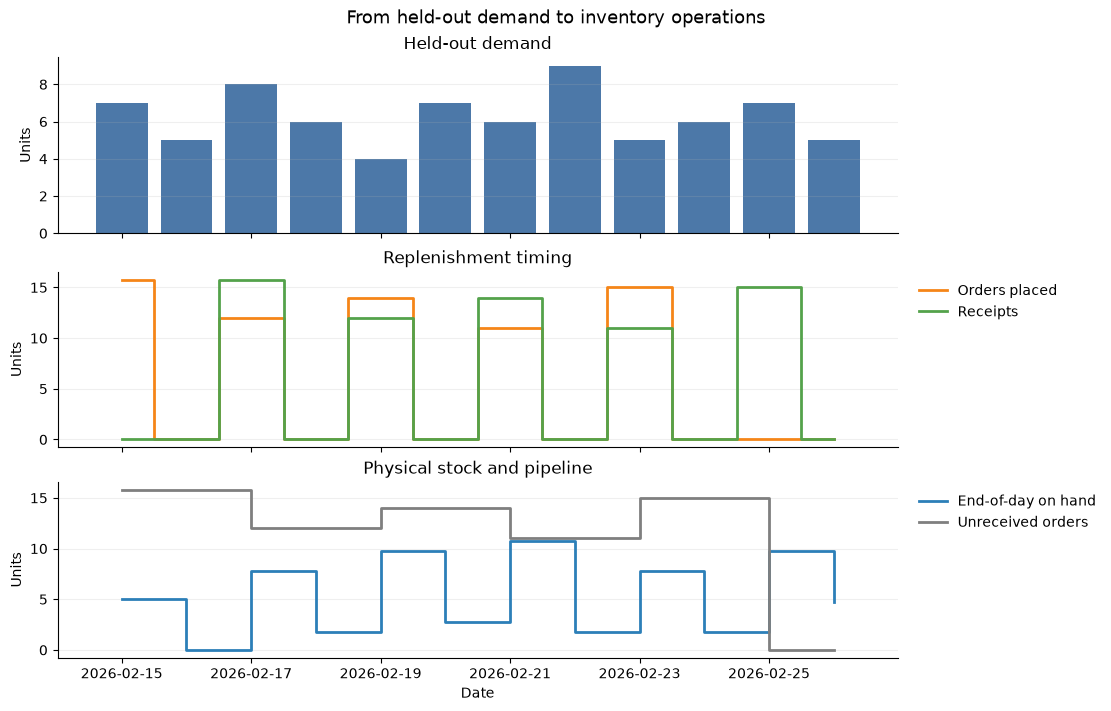

In [23]:
# Separate panels prevent differently scaled flows and states from competing.
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, layout='constrained')

axes[0].bar(period_events['date'], period_events['demand'], color='#4C78A8')
axes[0].set(title='Held-out demand', ylabel='Units')

axes[1].step(period_events['date'], period_events['order_quantity'], where='mid', color='#F58518', linewidth=2, label='Orders placed')
axes[1].step(period_events['date'], period_events['received_units'], where='mid', color='#54A24B', linewidth=2, label='Receipts')
axes[1].set(title='Replenishment timing', ylabel='Units')

axes[2].step(period_events['date'], period_events['ending_on_hand'], where='post', color='#2C7FB8', linewidth=2, label='End-of-day on hand')
axes[2].step(period_events['date'], period_events['on_order_end'], where='post', color='#7F7F7F', linewidth=2, label='Unreceived orders')
axes[2].set(title='Physical stock and pipeline', xlabel='Date', ylabel='Units')

# Put the keys outside the data area so no trajectory is hidden.
axes[1].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
axes[2].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
for ax in axes:
    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('From held-out demand to inventory operations', fontsize=13)
plt.show()


## Takeaway

Smooth produced a cumulative demand distribution for the four-day protection horizon. Its upper bound became the policy target. Stockcast then converted that target into orders, moved accepted orders through the lead-time pipeline, and evaluated the resulting service and inventory levels on held-out demand.

The forecast informed the decision; Stockcast accounted for its operational consequences.